# Codveda Technologies — Data Analytics Internship
## Level 1: Basic Data Analysis

---

| Detail | Information |
|---|---|
| **Intern Name** | Omokhoa Oshose Tosayoname |
| **Intern ID** | CV/A1/61250 |
| **Position** | Data Analysis Intern |
| **Organisation** | Codveda Technologies |
| **Level** | 1 — Basic |
| **Tasks Completed** | Task 2: Exploratory Data Analysis (EDA) · Task 3: Basic Data Visualisation |
| **Dataset** | Iris Dataset (iris.csv) |
| **Tools** | Python, pandas, matplotlib, seaborn |
| **Date** | March 2026 |

---

## Overview

This notebook presents the completed work for **Level 1 (Basic)** of the Codveda Technologies Data Analytics Internship.  
Two tasks are covered:

- **Task 2 — Exploratory Data Analysis (EDA):** Understanding the structure of the Iris dataset through summary statistics, central tendency measures, and correlation analysis.
- **Task 3 — Basic Data Visualisation:** Communicating data insights through histograms, boxplots, scatter plots, bar plots, line charts, and a correlation heatmap.

The Iris dataset is one of the most well-known datasets in data science, containing measurements of 150 iris flowers across three species: *Iris setosa*, *Iris versicolor*, and *Iris virginica*.

---

## Table of Contents

1. [Environment Setup](#1-environment-setup)
2. [Dataset Loading and Initial Exploration](#2-dataset-loading-and-initial-exploration)
3. [Task 2 — Exploratory Data Analysis](#3-task-2--exploratory-data-analysis-eda)
   - [3.1 Data Cleaning](#31-data-cleaning)
   - [3.2 Summary Statistics](#32-summary-statistics)
   - [3.3 Correlation Analysis](#33-correlation-analysis)
4. [Task 3 — Basic Data Visualisation](#4-task-3--basic-data-visualisation)
   - [4.1 Histograms](#41-histograms)
   - [4.2 Boxplots](#42-boxplots)
   - [4.3 Scatter Plots](#43-scatter-plots)
   - [4.4 Correlation Heatmap](#44-correlation-heatmap)
   - [4.5 Bar Plot](#45-bar-plot)
   - [4.6 Line Charts](#46-line-charts)
5. [Key Findings and Conclusions](#5-key-findings-and-conclusions)


---
## 1. Environment Setup

All required libraries are imported in a single cell below. This is best practice — keeping all imports together at the top of the notebook makes dependencies immediately visible to anyone reviewing the code.

- **pandas** — data loading, manipulation, and summary statistics
- **matplotlib** — foundational plotting library
- **seaborn** — high-level statistical visualisation built on matplotlib
- **warnings** — suppresses non-critical warnings for cleaner output


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')

# Set consistent plot styling throughout the notebook
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

# Create outputs directory if it doesn't exist
os.makedirs('outputs', exist_ok=True)

print("✓ All libraries imported successfully.")
print(f"  pandas     version: {pd.__version__}")
print(f"  numpy      version: {np.__version__}")
print(f"  matplotlib version: {matplotlib.__version__}")
print(f"  seaborn    version: {sns.__version__}")


✓ All libraries imported successfully.
  pandas     version: 2.2.2
  numpy      version: 2.0.2
  matplotlib version: 3.10.0
  seaborn    version: 0.13.2


---
## 2. Dataset Loading and Initial Exploration

Before any analysis begins, we must understand what we are working with. This section loads the dataset and performs an initial inspection to answer fundamental questions:

- How many rows and columns are there?
- What data types are present?
- Are there any missing values?
- Are there any duplicate records?
- What does a sample of the data look like?


In [2]:
# Load the Iris dataset
df = pd.read_csv('datasets/iris.csv')

print("=" * 55)
print("DATASET OVERVIEW")
print("=" * 55)
print(f"Shape        : {df.shape[0]} rows × {df.shape[1]} columns")
print(f"Columns      : {df.columns.tolist()}")
print(f"Duplicate rows: {df.duplicated().sum()}")
print(f"Missing values: {df.isnull().sum().sum()}")
print()
print("DATA TYPES:")
print(df.dtypes)
print()
print("FIRST 5 ROWS:")
df.head()


DATASET OVERVIEW
Shape        : 150 rows × 5 columns
Columns      : ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']
Duplicate rows: 3
Missing values: 0

DATA TYPES:
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object

FIRST 5 ROWS:


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [3]:
# Species distribution — checking class balance
print("SPECIES DISTRIBUTION:")
print(df['species'].value_counts())
print()
print("UNIQUE SPECIES:", df['species'].unique().tolist())


SPECIES DISTRIBUTION:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

UNIQUE SPECIES: ['setosa', 'versicolor', 'virginica']


### Initial Observations

From the exploration above, several important facts emerge:

- The dataset contains **150 rows and 5 columns** — four numerical feature columns and one categorical target column (`species`).
- All four numerical columns (`sepal_length`, `sepal_width`, `petal_length`, `petal_width`) are stored as `float64`, which is appropriate for continuous measurements in centimetres.
- There are **no missing values**, making this a clean dataset requiring minimal preprocessing.
- There are **3 duplicate rows** which will be removed before analysis to avoid skewing results.
- The three species (*setosa*, *versicolor*, *virginica*) are **perfectly balanced** — each has exactly 50 records. This is important because a balanced dataset produces more reliable summary statistics and visualisations.


---
## 3. Task 2 — Exploratory Data Analysis (EDA)

**Task Description:** Perform an exploratory analysis on the Iris dataset to identify patterns, trends, and summary statistics.

**Objectives:**
- Calculate summary statistics (mean, median, mode, standard deviation)
- Visualise data distributions using histograms, boxplots, and scatter plots
- Find correlations between numerical features

Exploratory Data Analysis (EDA) is the process of examining a dataset to summarise its main characteristics — often before any formal modelling or hypothesis testing. It is the foundation of every data analysis project.


### 3.1 Data Cleaning

Although the Iris dataset is largely clean, we must address the **3 duplicate rows** identified during initial exploration. Leaving duplicates in place would cause those specific flower measurements to count twice in all calculations, subtly biasing means, standard deviations, and correlation values.


In [4]:
# Remove duplicate rows
print(f"Rows before removing duplicates : {len(df)}")
df = df.drop_duplicates()
print(f"Rows after removing duplicates  : {len(df)}")
print(f"Duplicates remaining            : {df.duplicated().sum()}")

# Reset the index after dropping rows
df = df.reset_index(drop=True)
print()
print("✓ Dataset cleaned. Ready for analysis.")


Rows before removing duplicates : 150
Rows after removing duplicates  : 147
Duplicates remaining            : 0

✓ Dataset cleaned. Ready for analysis.


### 3.2 Summary Statistics

Summary statistics provide a numerical portrait of the data. We calculate:

- **Mean** — the arithmetic average; represents the central value
- **Median** — the middle value when sorted; robust to outliers
- **Mode** — the most frequently occurring value
- **Standard Deviation** — measures how spread out values are around the mean; a high std means high variability

We calculate these both **overall** (across all 147 records) and **by species** to understand how the three flower types differ.


In [5]:
# Define numerical columns
numerical = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

print("=" * 60)
print("OVERALL SUMMARY STATISTICS")
print("=" * 60)
df[numerical].describe().round(2)


OVERALL SUMMARY STATISTICS


,sepal_length,sepal_width,petal_length,petal_width
count,147.00,147.00,147.00,147.00
mean,5.86,3.06,3.78,1.21
std,0.83,0.44,1.76,0.76
min,4.30,2.00,1.00,0.10
25%,5.10,2.80,1.60,0.30
50%,5.80,3.00,4.40,1.30
75%,6.40,3.30,5.10,1.80
max,7.90,4.40,6.90,2.50


In [6]:
print("MEAN:")
print(df[numerical].mean().round(2))
print()
print("MEDIAN:")
print(df[numerical].median().round(2))
print()
print("MODE:")
print(df[numerical].mode().iloc[0].round(2))
print()
print("STANDARD DEVIATION:")
print(df[numerical].std().round(2))


MEAN:
sepal_length    5.86
sepal_width     3.06
petal_length    3.78
petal_width     1.21
dtype: float64

MEDIAN:
sepal_length    5.8
sepal_width     3.0
petal_length    4.4
petal_width     1.3
dtype: float64

MODE:
sepal_length    5.0
sepal_width     3.0
petal_length    1.4
petal_width     0.2
Name: 0, dtype: float64

STANDARD DEVIATION:
sepal_length    0.83
sepal_width     0.44
petal_length    1.76
petal_width     0.76
dtype: float64


In [7]:
print("=" * 60)
print("SUMMARY STATISTICS BY SPECIES")
print("=" * 60)
df.groupby('species')[numerical].mean().round(2)


SUMMARY STATISTICS BY SPECIES


,sepal_length,sepal_width,petal_length,petal_width
species,,,,
setosa,5.01,3.43,1.46,0.25
versicolor,5.94,2.77,4.26,1.33
virginica,6.60,2.98,5.56,2.03


### Interpretation of Summary Statistics

The per-species means reveal the most important patterns in this dataset:

| Feature | Setosa | Versicolor | Virginica |
|---|---|---|---|
| Sepal Length | 5.01 cm | 5.94 cm | 6.60 cm |
| Sepal Width | 3.43 cm | 2.77 cm | 2.98 cm |
| Petal Length | 1.46 cm | 4.26 cm | 5.56 cm |
| Petal Width | 0.25 cm | 1.33 cm | 2.03 cm |

**Key observations:**
- **Petal length** shows the most dramatic variation between species (std = 1.76), making it the most discriminating feature.
- **Sepal width** is the most consistent feature across the dataset (std = 0.44).
- *Setosa* is distinctly smaller in all petal measurements, making it easily separable from the other two species.
- *Virginica* is the largest species across nearly every dimension.


### 3.3 Correlation Analysis

Correlation measures the strength and direction of the linear relationship between two numerical variables. The Pearson correlation coefficient ranges from **-1** (perfect negative) to **+1** (perfect positive), with **0** indicating no linear relationship.

Understanding correlations is critical because:
- Highly correlated features may be redundant in machine learning models
- Correlations reveal which measurements tend to vary together across species


In [8]:
corr = df[numerical].corr().round(2)

print("CORRELATION MATRIX:")
print(corr)
print()
print("PAIRWISE INTERPRETATION:")
for i in range(len(numerical)):
    for j in range(i+1, len(numerical)):
        val = corr.iloc[i, j]
        if abs(val) > 0.7:
            strength = "STRONG"
        elif abs(val) > 0.4:
            strength = "MODERATE"
        else:
            strength = "WEAK"
        direction = "positive" if val > 0 else "negative"
        print(f"  {numerical[i]} vs {numerical[j]}: r = {val:.2f} ({strength} {direction})")


CORRELATION MATRIX:
              sepal_length  sepal_width  petal_length  petal_width
sepal_length          1.00        -0.11          0.87         0.82
sepal_width          -0.11         1.00         -0.42        -0.36
petal_length          0.87        -0.42          1.00         0.96
petal_width           0.82        -0.36          0.96         1.00

PAIRWISE INTERPRETATION:
  sepal_length vs sepal_width: r = -0.11 (WEAK negative)
  sepal_length vs petal_length: r = 0.87 (STRONG positive)
  sepal_length vs petal_width: r = 0.82 (STRONG positive)
  sepal_width vs petal_length: r = -0.42 (MODERATE negative)
  sepal_width vs petal_width: r = -0.36 (WEAK negative)
  petal_length vs petal_width: r = 0.96 (STRONG positive)


### Interpretation of Correlations

The most striking finding is the **r = 0.96** correlation between `petal_length` and `petal_width` — an almost perfect positive relationship. As petals grow longer, they also grow proportionally wider. This makes biological sense.

`sepal_length` also correlates strongly with both petal dimensions (r = 0.87 and r = 0.82), suggesting that overall flower size tends to scale together.

`sepal_width` has an almost zero correlation with `sepal_length` (r = −0.11), meaning knowing a flower's sepal width tells us almost nothing about its sepal length. This counterintuitive finding is partly explained by the mixing of species — within each individual species, the correlation is actually positive, but across all three species combined, *setosa*'s wide sepals and small overall size create a negative pattern. This phenomenon is known as **Simpson's Paradox**.


---
## 4. Task 3 — Basic Data Visualisation

**Task Description:** Create basic plots and charts to visualise the distribution and relationships within the Iris dataset.

**Objectives:**
- Create bar plots, line charts, and scatter plots
- Customise plot labels, titles, and legends
- Export plots as images for reports

Visualisation transforms numbers into stories. Each chart type serves a specific purpose — histograms show distribution shape, boxplots reveal spread and outliers, scatter plots reveal relationships, and bar plots compare groups.

A consistent colour palette is used throughout: **Blue (#4C72B0)** for *setosa*, **Green (#55A868)** for *versicolor*, **Red (#C44E52)** for *virginica*.


### 4.1 Histograms — Distribution of Each Feature

A histogram divides a numerical variable into bins (intervals) and counts how many values fall into each bin. The shape of the histogram reveals whether data is normally distributed, skewed, or multimodal.

Here we plot all four features simultaneously, with each species overlaid in a different colour. This allows us to see not just the overall distribution but how each species contributes to it.


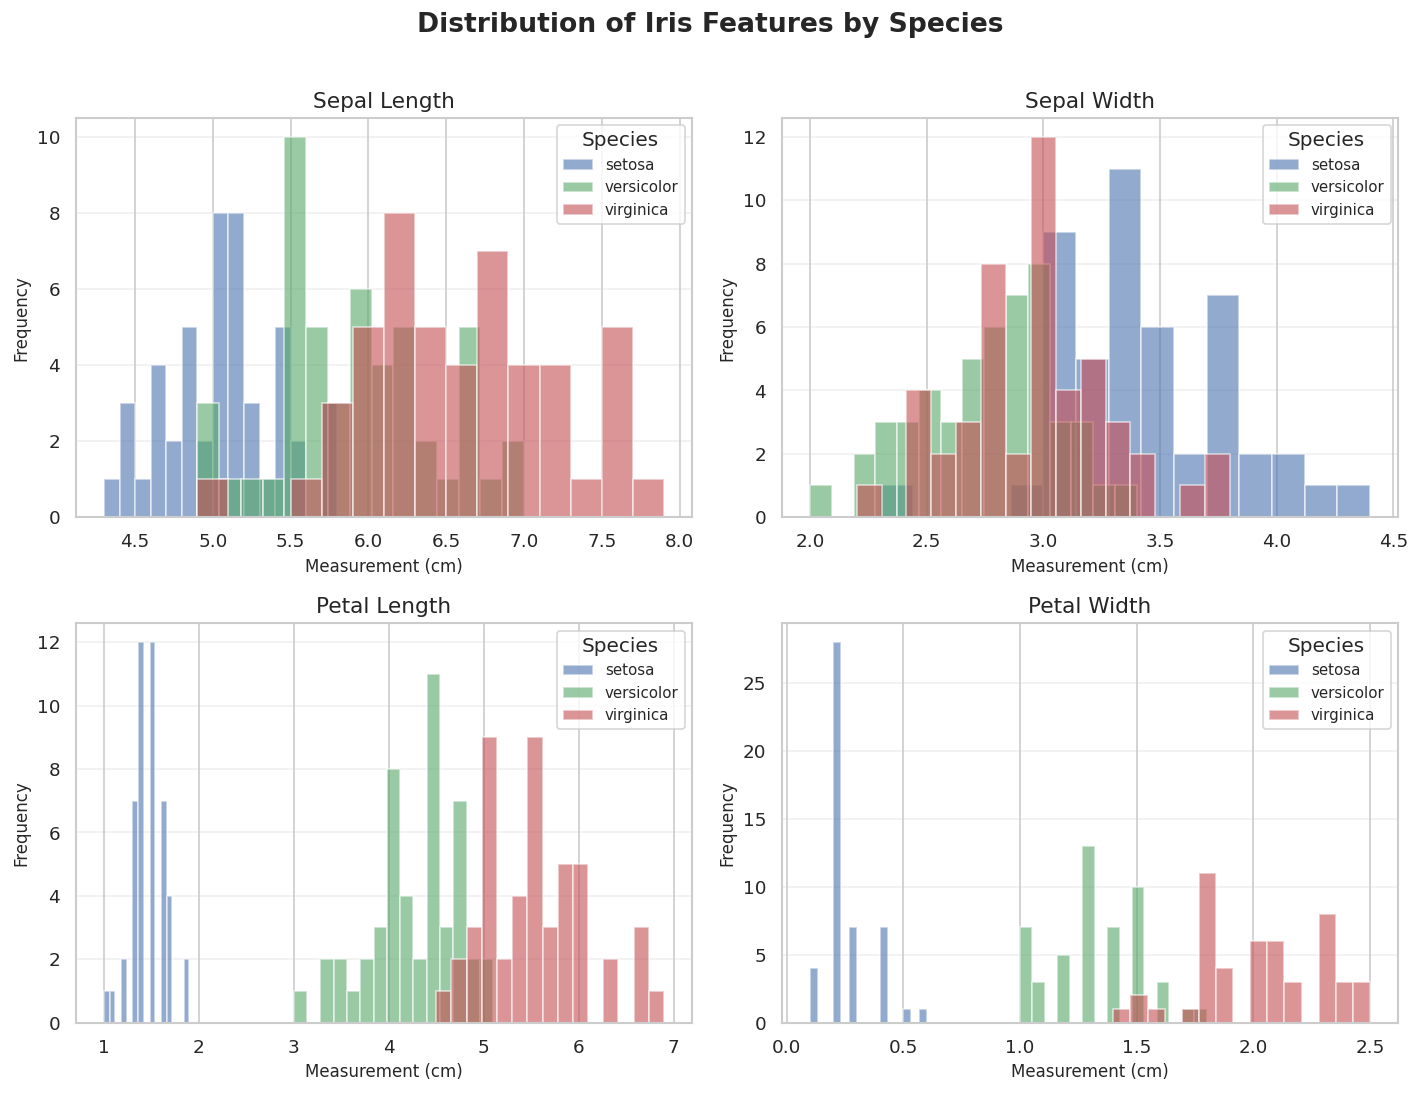

✓ Histogram saved to outputs/01_histograms.png


In [9]:
colors = {'setosa': '#4C72B0', 'versicolor': '#55A868', 'virginica': '#C44E52'}

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
fig.suptitle('Distribution of Iris Features by Species',
             fontsize=16, fontweight='bold', y=1.01)

for ax, col in zip(axes.flatten(), numerical):
    for species, group in df.groupby('species'):
        ax.hist(group[col], bins=15, alpha=0.6, label=species,
                color=colors[species], edgecolor='white')
    ax.set_title(col.replace('_', ' ').title(), fontsize=13)
    ax.set_xlabel('Measurement (cm)', fontsize=10)
    ax.set_ylabel('Frequency', fontsize=10)
    ax.legend(title='Species', fontsize=9)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/01_histograms.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Histogram saved to outputs/01_histograms.png")


**Insight:** The petal length and petal width histograms show a clear bimodal distribution — *setosa* values cluster tightly at the low end, completely separated from *versicolor* and *virginica* which overlap in the middle-to-high range. The sepal width histogram shows the most overlap between species, confirming its weak discriminating power.


### 4.2 Boxplots — Spread and Outliers

A boxplot (box-and-whisker plot) summarises five key statistics simultaneously:
- The **box** spans from the 25th percentile (Q1) to the 75th percentile (Q3) — the interquartile range (IQR)
- The **line inside the box** is the median (50th percentile)
- The **whiskers** extend to 1.5 × IQR beyond the box edges
- **Dots beyond the whiskers** are statistical outliers

Boxplots are particularly useful for comparing distributions across groups (species in this case).


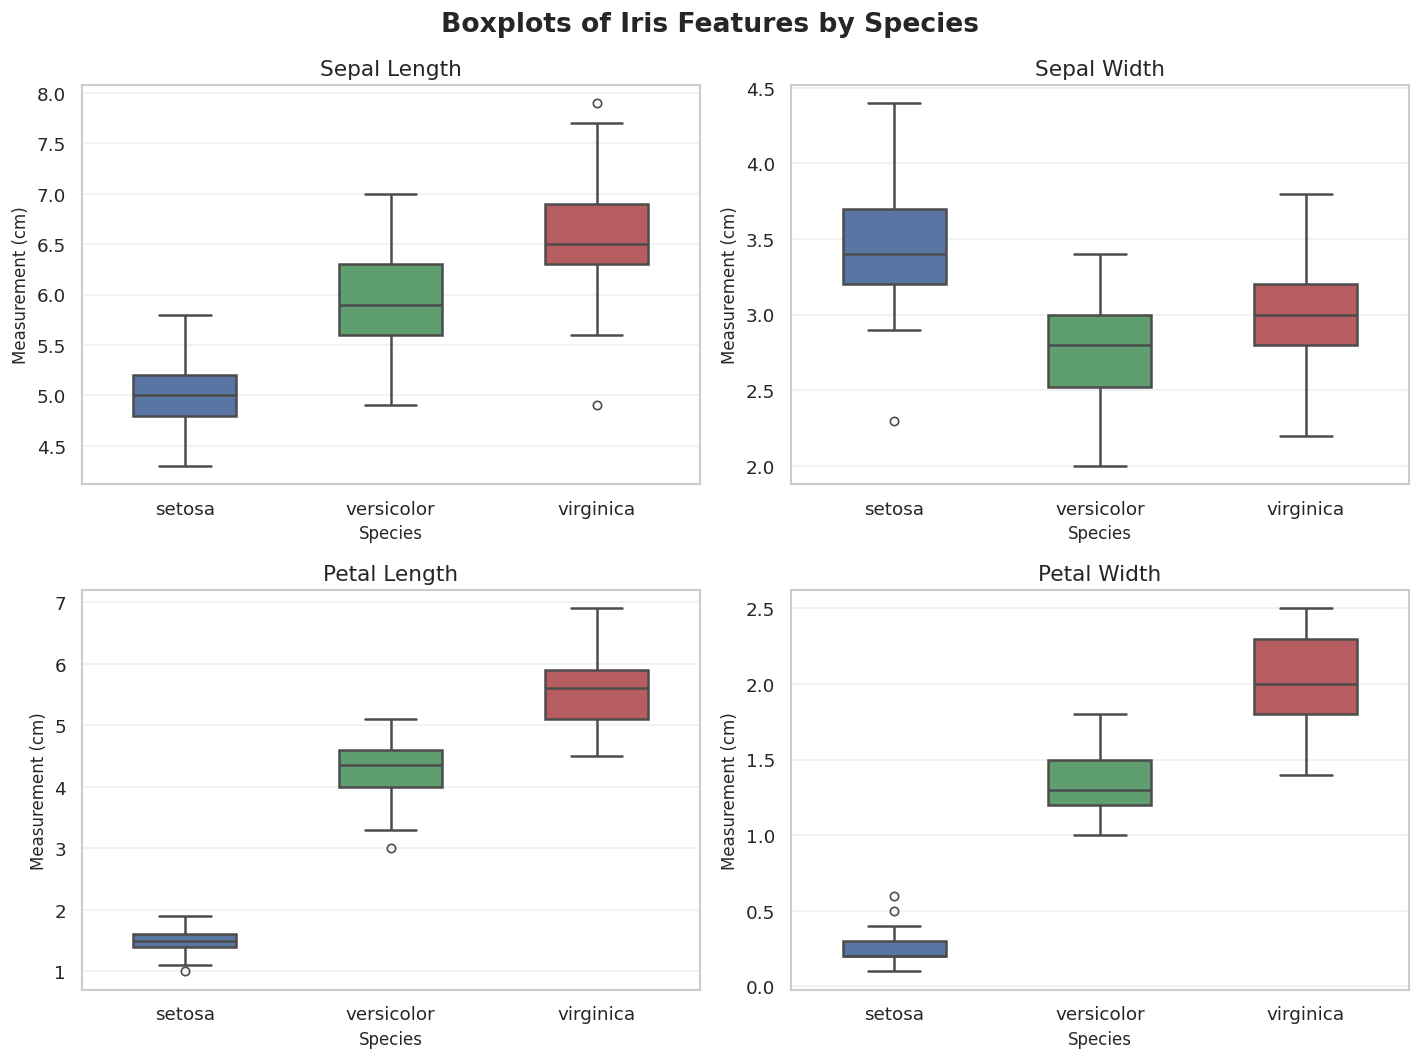

✓ Boxplot saved to outputs/02_boxplots.png


In [10]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
fig.suptitle('Boxplots of Iris Features by Species',
             fontsize=16, fontweight='bold')

for ax, col in zip(axes.flatten(), numerical):
    sns.boxplot(data=df, x='species', y=col, hue='species', ax=ax,
                palette=colors, width=0.5, linewidth=1.5,
                flierprops=dict(marker='o', markersize=5), legend=False)
    ax.set_title(col.replace('_', ' ').title(), fontsize=13)
    ax.set_xlabel('Species', fontsize=10)
    ax.set_ylabel('Measurement (cm)', fontsize=10)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/02_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Boxplot saved to outputs/02_boxplots.png")


**Insight:** The boxplots confirm the separation between species. *Setosa* petal measurements have very narrow boxes (low variability) positioned far below the other two species. *Virginica* consistently occupies the top range. Several outlier dots are visible — individual flowers that measured unusually high or low relative to their species.


### 4.3 Scatter Plots — Relationships Between Features

Scatter plots place two variables on X and Y axes, with one dot per observation. They reveal the nature of the relationship between two variables — linear, non-linear, or absent. Colouring by species reveals whether the natural groupings are visible in two-dimensional space.

We plot two contrasting pairs:
1. **Petal Length vs Petal Width** (strongest correlation: r = 0.96)
2. **Sepal Length vs Sepal Width** (weakest correlation: r = −0.11)


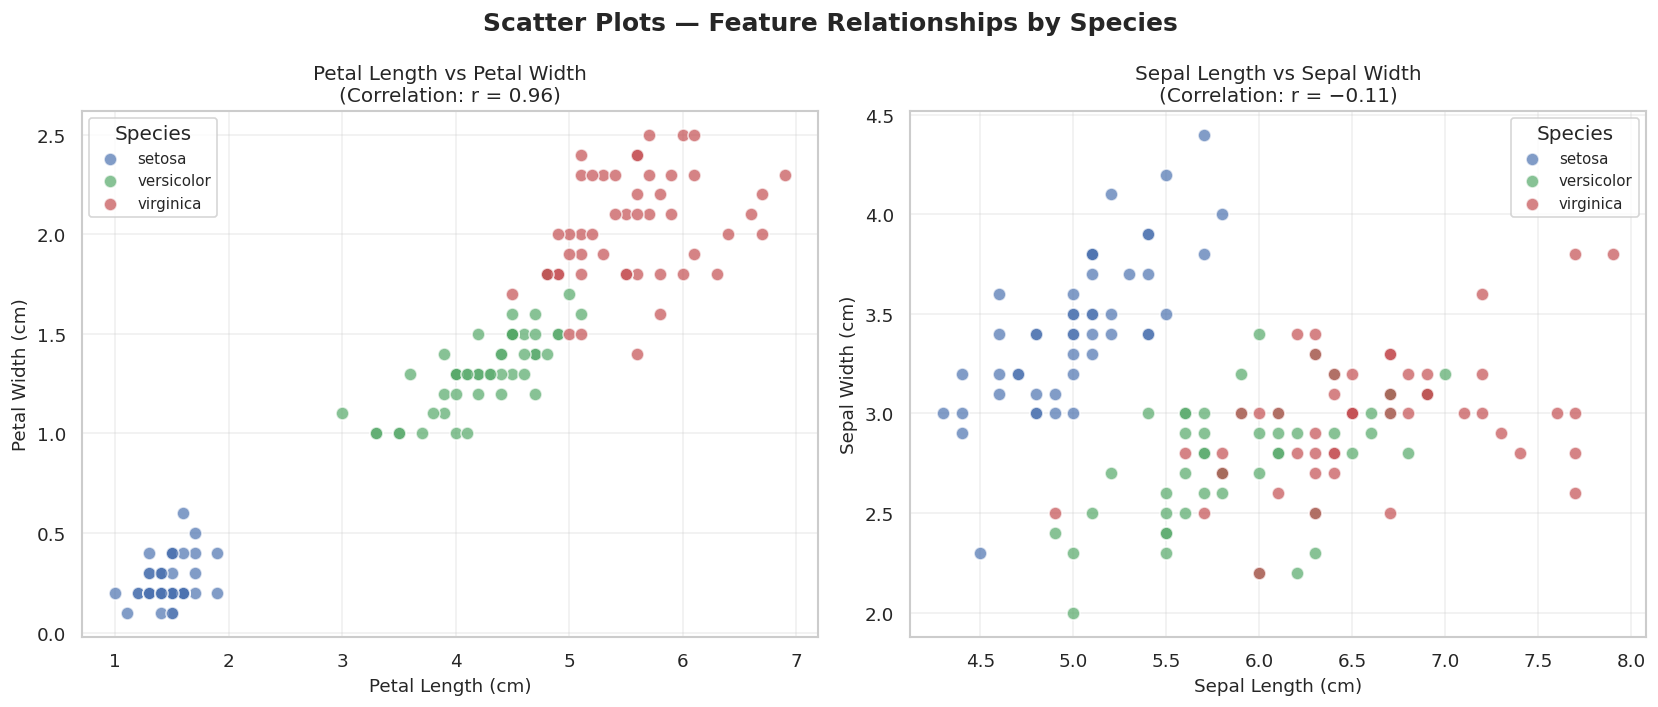

✓ Scatter plots saved to outputs/03_scatter_plots.png


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Scatter Plots — Feature Relationships by Species',
             fontsize=15, fontweight='bold')

# Plot 1: Strongest correlation
for species, group in df.groupby('species'):
    axes[0].scatter(group['petal_length'], group['petal_width'],
                    label=species, color=colors[species],
                    alpha=0.7, s=60, edgecolors='white')
axes[0].set_title('Petal Length vs Petal Width\n(Correlation: r = 0.96)', fontsize=12)
axes[0].set_xlabel('Petal Length (cm)', fontsize=11)
axes[0].set_ylabel('Petal Width (cm)', fontsize=11)
axes[0].legend(title='Species', fontsize=9)
axes[0].grid(alpha=0.3)

# Plot 2: Weakest correlation
for species, group in df.groupby('species'):
    axes[1].scatter(group['sepal_length'], group['sepal_width'],
                    label=species, color=colors[species],
                    alpha=0.7, s=60, edgecolors='white')
axes[1].set_title('Sepal Length vs Sepal Width\n(Correlation: r = −0.11)', fontsize=12)
axes[1].set_xlabel('Sepal Length (cm)', fontsize=11)
axes[1].set_ylabel('Sepal Width (cm)', fontsize=11)
axes[1].legend(title='Species', fontsize=9)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/03_scatter_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Scatter plots saved to outputs/03_scatter_plots.png")


**Insight:** The petal scatter plot (left) shows three remarkably clean clusters — *setosa* sits isolated in the bottom-left corner, completely separated from the other two species. This is one of the most famous patterns in data science and explains why *setosa* is always the easiest species to classify in machine learning experiments. The sepal scatter plot (right) shows significantly more overlap between all three species.


### 4.4 Correlation Heatmap — Visual Summary of Feature Relationships

A heatmap encodes the correlation matrix as colours, making patterns immediately visible at a glance. Green cells indicate strong positive correlations, red cells indicate negative correlations, and white/yellow cells indicate weak or no correlation.


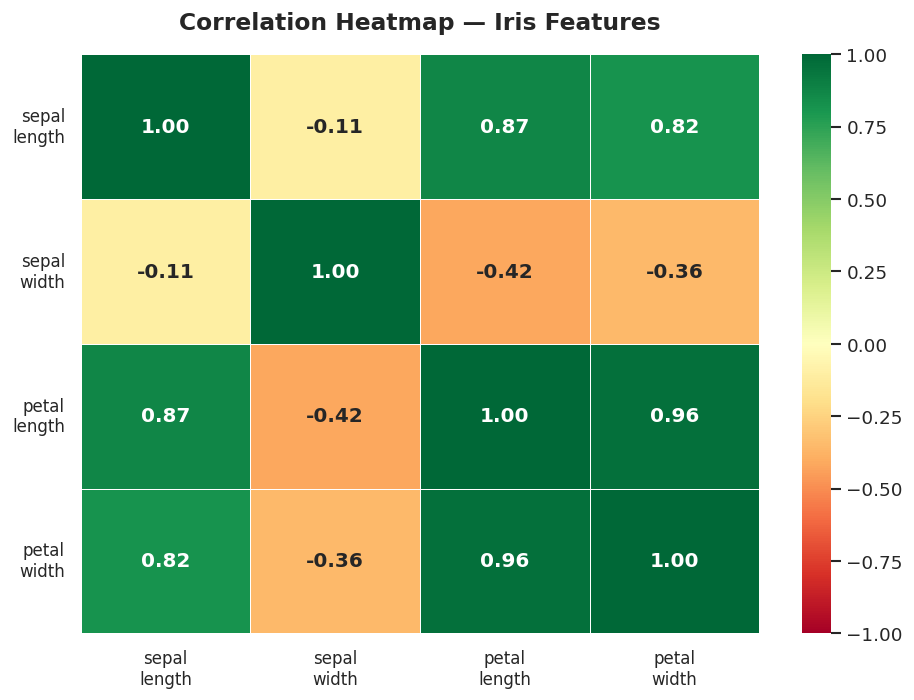

✓ Heatmap saved to outputs/04_correlation_heatmap.png


In [12]:
fig, ax = plt.subplots(figsize=(8, 6))
corr_matrix = df[numerical].corr()

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            vmin=-1, vmax=1, ax=ax, linewidths=0.5,
            annot_kws={'size': 12, 'weight': 'bold'})

ax.set_title('Correlation Heatmap — Iris Features',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xticklabels([c.replace('_', '\n') for c in numerical], fontsize=10)
ax.set_yticklabels([c.replace('_', '\n') for c in numerical],
                   fontsize=10, rotation=0)

plt.tight_layout()
plt.savefig('outputs/04_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Heatmap saved to outputs/04_correlation_heatmap.png")


**Insight:** The deep green cell at the intersection of `petal_length` and `petal_width` (r = 0.96) is immediately striking. The near-zero value between `sepal_length` and `sepal_width` (r = −0.11) is equally notable — these two sepal dimensions are essentially independent of each other across the full dataset.


### 4.5 Bar Plot — Mean Feature Values by Species

Bar plots compare a numerical value across categories. Here we compare the mean measurement of each feature across the three species, grouped side by side for easy visual comparison.

Value labels are added above each bar to make precise comparisons possible without reading the axis.


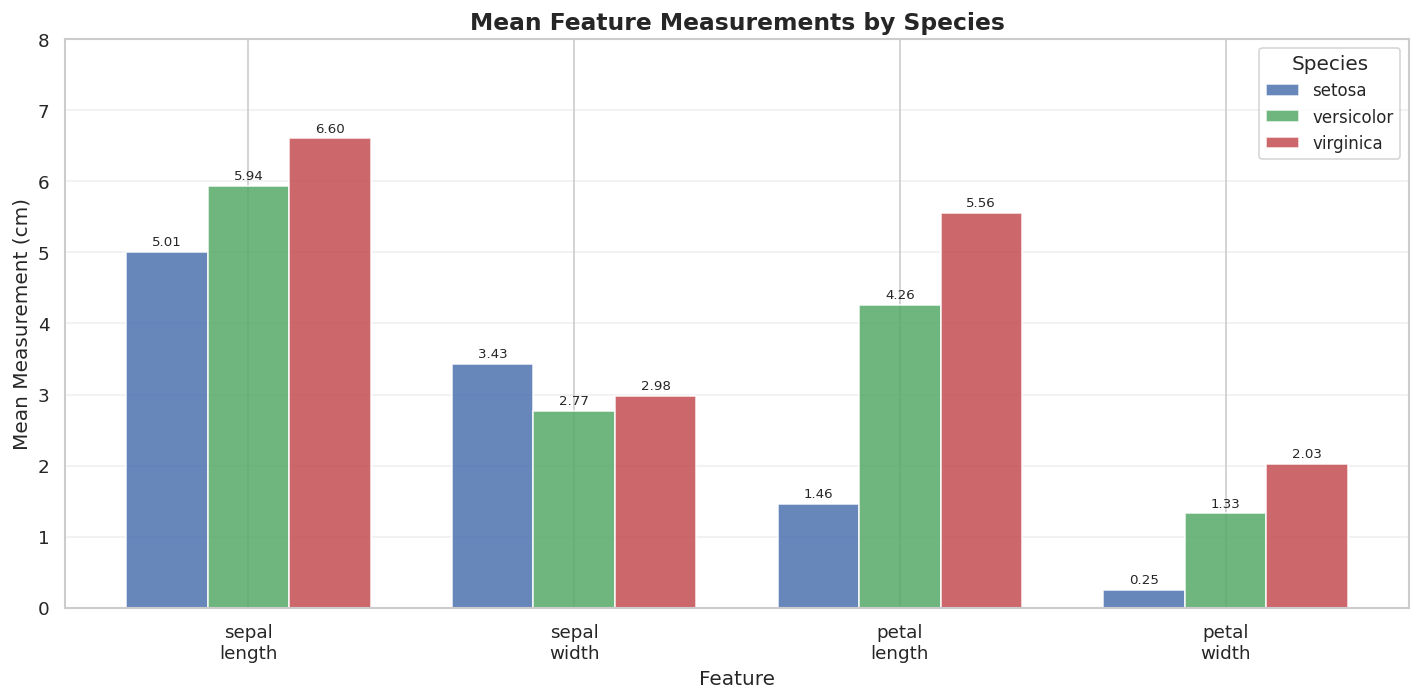

✓ Bar plot saved to outputs/05_bar_plot.png


In [13]:
species_means = df.groupby('species')[numerical].mean()
species_list = species_means.index.tolist()
x = np.arange(len(numerical))
width = 0.25
bar_colors = ['#4C72B0', '#55A868', '#C44E52']

fig, ax = plt.subplots(figsize=(12, 6))

for i, (species, color) in enumerate(zip(species_list, bar_colors)):
    bars = ax.bar(x + i * width, species_means.loc[species],
                  width, label=species, color=color,
                  alpha=0.85, edgecolor='white')
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2.,
                bar.get_height() + 0.05,
                f'{bar.get_height():.2f}',
                ha='center', va='bottom', fontsize=8)

ax.set_title('Mean Feature Measurements by Species',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Feature', fontsize=12)
ax.set_ylabel('Mean Measurement (cm)', fontsize=12)
ax.set_xticks(x + width)
ax.set_xticklabels([c.replace('_', '\n') for c in numerical], fontsize=11)
ax.legend(title='Species', fontsize=10)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, 8)

plt.tight_layout()
plt.savefig('outputs/05_bar_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Bar plot saved to outputs/05_bar_plot.png")


**Insight:** The bar plot makes the size progression crystal clear — *setosa* is consistently the smallest (especially in petal dimensions), *versicolor* sits in the middle, and *virginica* is the largest across nearly every measurement. The most dramatic difference is in petal length: *setosa* averages 1.46 cm vs *virginica* at 5.56 cm — a nearly 4× difference within the same genus.


### 4.6 Line Charts — Feature Values Across Samples

Line charts connect data points sequentially, making them ideal for showing trends over an ordered sequence. Here we plot each feature value across sample indices, with each species represented by a separate line colour. This reveals the consistency (or variability) of measurements within each species across all recorded samples.


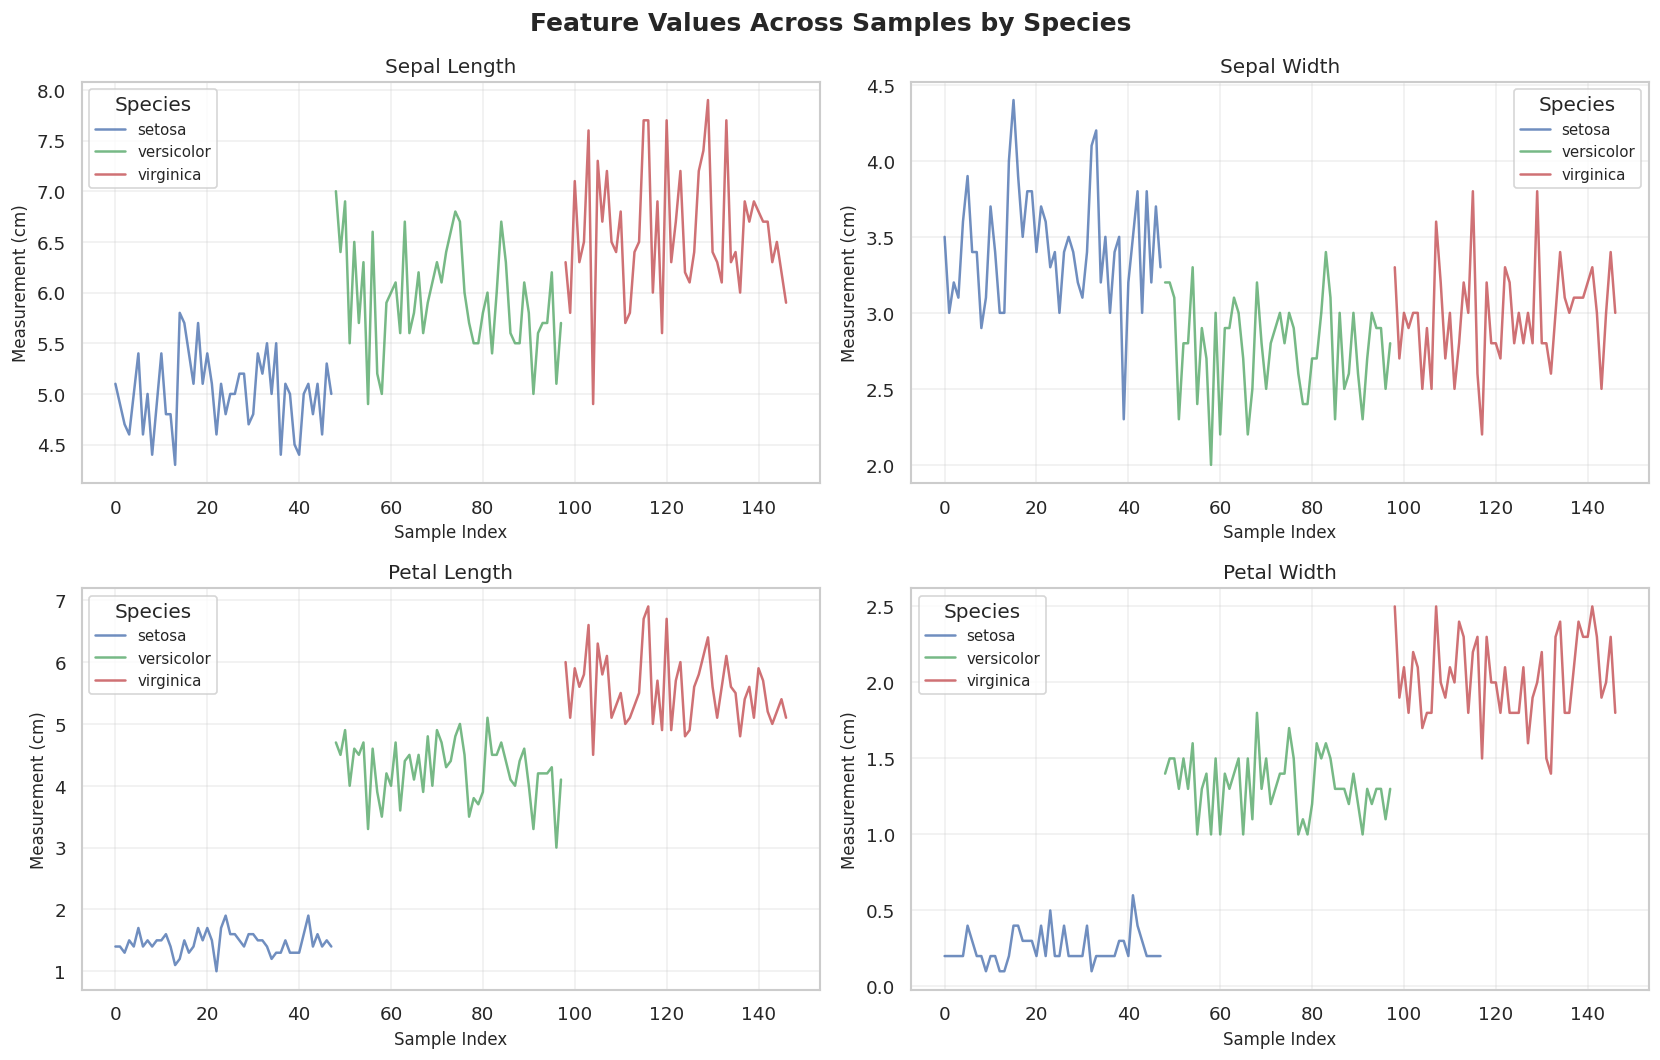

✓ Line charts saved to outputs/06_line_charts.png


In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Feature Values Across Samples by Species',
             fontsize=15, fontweight='bold')

for ax, col in zip(axes.flatten(), numerical):
    for species, group in df.groupby('species'):
        ax.plot(group.index, group[col], label=species,
                color=colors[species], alpha=0.8, linewidth=1.5)
    ax.set_title(col.replace('_', ' ').title(), fontsize=12)
    ax.set_xlabel('Sample Index', fontsize=10)
    ax.set_ylabel('Measurement (cm)', fontsize=10)
    ax.legend(title='Species', fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/06_line_charts.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Line charts saved to outputs/06_line_charts.png")


**Insight:** The petal measurement line charts show three visually distinct horizontal bands — *setosa* running flat and low, *versicolor* in the middle, and *virginica* at the top. The sepal width chart is noticeably more interleaved, with all three species overlapping — consistent with the weak correlation and lower discriminating power we identified earlier.


---
## 5. Key Findings and Conclusions

### Task 2 — EDA Findings

| Finding | Detail |
|---|---|
| Dataset size | 147 records × 5 columns (after removing 3 duplicates) |
| Missing values | None |
| Most variable feature | Petal length (std = 1.76 cm) |
| Most consistent feature | Sepal width (std = 0.44 cm) |
| Strongest correlation | Petal length vs Petal width (r = 0.96) |
| Weakest correlation | Sepal length vs Sepal width (r = −0.11) |
| Most separable species | *Iris setosa* (distinctly small petals) |
| Most similar species pair | *Versicolor* and *virginica* (overlapping in all features) |

### Task 3 — Visualisation Summary

Six chart types were produced, each serving a distinct analytical purpose:

| Chart | Purpose | Key Insight |
|---|---|---|
| Histograms | Distribution shape | Setosa petals cluster far below other species |
| Boxplots | Spread and outliers | Virginica has widest spread; setosa most consistent |
| Scatter plots | Feature relationships | Petal dimensions form near-perfect linear clusters |
| Heatmap | Correlation overview | Petal features are almost perfectly correlated |
| Bar plot | Group comparison | Virginica largest across all features |
| Line charts | Sequential patterns | Petal bands are clearly species-separated |

### Overall Conclusion

The Iris dataset, despite its simplicity, contains rich structure that EDA techniques reveal effectively. The most important finding is that **petal measurements are far more informative than sepal measurements** for distinguishing between species. *Iris setosa* is trivially separable from the other two species based on petal size alone, while *versicolor* and *virginica* require more nuanced analysis to differentiate.

These findings lay the groundwork for the intermediate-level tasks in Level 2, where machine learning techniques will be applied to formally discover and validate these natural groupings.

---

*Notebook prepared by Omokhoa Oshose Tosayoname | Codveda Technologies Data Analytics Internship | March 2026*
